# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [16]:
# !pip install git+https://github.com/huggingface/transformers datasets bitsandbytes 'accelerate>=0.26.0' typing_extensions==4.7.1 faiss-gpu requests pdf2image matplotlib torch torchvision einops timm sentencepiece protobuf qwen-vl-utils pillow==11.1.0
# !pip install flash-attn --no-build-isolation

### imports

In [1]:
from datasets import load_dataset, Dataset
import torchvision.transforms as T
from utils.utils import get_device, plot_images
import torch
from utils.attack import rag_attack
from collections import defaultdict
from utils.embedding import EmbeddingModel, add_img_embedding_column, retrieve_images_by_prompt
from utils.vlm import VLM
from utils.scheduler import LearningRateScheduler

### Load Dataset

In [2]:
ds = load_dataset("vidore/syntheticDocQA_artificial_intelligence_test", split='test')
ds

Dataset({
    features: ['query', 'image', 'image_filename', 'answer', 'page', 'model', 'prompt', 'source'],
    num_rows: 1000
})

### Config

In [3]:
device = get_device(prefer_mps=True)
model_name_emb = "openai/clip-vit-base-patch16" # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = "HuggingFaceTB/SmolVLM-500M-Instruct" # "HuggingFaceTB/SmolVLM-256M-Instruct", "HuggingFaceTB/SmolVLM-500M-Instruct", "microsoft/Florence-2-large", , "naver-clova-ix/donut-base-finetuned-docvqa", "Qwen/Qwen2.5-VL-3B-Instruct"
emb_loss_type = "mse" # mse, l2, cos
target_answer = "I will not reply to you!"
test_retrieval = False # whether to add adversarial image to dataset and test retrieval
test_generation = True

### Load Embedding Model & VLM

In [4]:
embedder = EmbeddingModel(model_name_emb, device)
vlm = VLM(model_name_vlm, device)

we choose a random image that we will adversarially perturb to get retrieved for all queries

In [5]:
chosen_index = 250
chosen_image = ds[chosen_index]['image']
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
chosen_image = chosen_image.type(embedder.model.dtype)
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Computing embeddings for the queries and their correct images

In [6]:
query_strings = ds[:100]['query']
if test_retrieval:
    images = ds[:100]['image']

    query_embeddings = embedder.compute_txt_embedding(query_strings)
    correct_img_embeddings = embedder.compute_img_embedding(images, None, overwrite=False)

    target_mses = torch.tensor([torch.nn.functional.mse_loss(qe, ie).item() for qe, ie in zip(query_embeddings, correct_img_embeddings)])

    chosen_img_embeddings = embedder.compute_img_embedding(chosen_image, chosen_image, overwrite=True)
    initial_mses = torch.tensor([torch.nn.functional.mse_loss(qe, chosen_img_embeddings[0]).item() for qe in query_embeddings])

### Compute the adversarial attack

In [7]:
# lr = 255*(3e-2) works well with cosine similarity
n_iter = 100
# chosen_image = chosen_image.to(torch.float32)
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    user_query=query_strings,
    target_answer=target_answer,
    max_perturbation=12.0/255,
    n_iter=n_iter,
    print_every=5,
    lr_scheduler=LearningRateScheduler(255*(3e-3), 255*(3e-4), n_iter),
    max_batch_size=8,
    lambda_emb=1,
    lambda_vlm=1,
    emb_loss_type=emb_loss_type,
    device=device
    )

/Users/ezaki/Library/CloudStorage/OneDrive-TheAlanTuringInstitute/Research/LLMSec/code/mumorag_gh/mumoRAG-attacks/src/utils/embedding.py:151: UserWarning: Using a target size (torch.Size([8, 512])) that is different to the input size (torch.Size([1, 512])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return torch.nn.functional.mse_loss(image_embedding, text_embedding)


Iter    1, Losses -> Embedding: 0.30762064, VLM: 10.37092590, Total: 10.67854691
Iter    5, Losses -> Embedding: 0.29004145, VLM: 8.81291103, Total: 9.10295296
Iter   10, Losses -> Embedding: 0.28017831, VLM: 7.37360477, Total: 7.65378284
Iter   15, Losses -> Embedding: 0.25662971, VLM: 4.50553226, Total: 4.76216221
Iter   20, Losses -> Embedding: 0.24952935, VLM: 4.23380899, Total: 4.48333836
Iter   25, Losses -> Embedding: 0.24518532, VLM: 3.46708727, Total: 3.71227264
Iter   30, Losses -> Embedding: 0.22202432, VLM: 3.54745650, Total: 3.76948071
Iter   35, Losses -> Embedding: 0.21163571, VLM: 2.68838763, Total: 2.90002346
Iter   40, Losses -> Embedding: 0.20982397, VLM: 3.03208899, Total: 3.24191284
Iter   45, Losses -> Embedding: 0.21222153, VLM: 2.65695620, Total: 2.86917782
Iter   50, Losses -> Embedding: 0.20986703, VLM: 2.58259201, Total: 2.79245901
Iter   55, Losses -> Embedding: 0.21440348, VLM: 2.30039454, Total: 2.51479793
Iter   60, Losses -> Embedding: 0.19631439, VLM: 2

In [8]:
if test_retrieval:
    target_mses = target_mses.to(device)

    init_mses = embedder.compare_embeddings(initial_chosen_image, query_strings, loss_type=emb_loss_type)
    adv_mses = embedder.compare_embeddings(image_adv.type(torch.int32), query_strings, loss_type=emb_loss_type)
    adv_mses_ow = embedder.compare_embeddings(image_adv.type(torch.int32), query_strings, overwrite=True, loss_type=emb_loss_type)

    num_success_init = sum(init_mses < target_mses).item()
    num_success_adv = sum(adv_mses < target_mses).item()
    num_success_adv_ow = sum(adv_mses_ow < target_mses).item()

    print(num_success_init, num_success_adv, num_success_adv_ow)

MSE: 25.440462112426758
Linf: 12.0


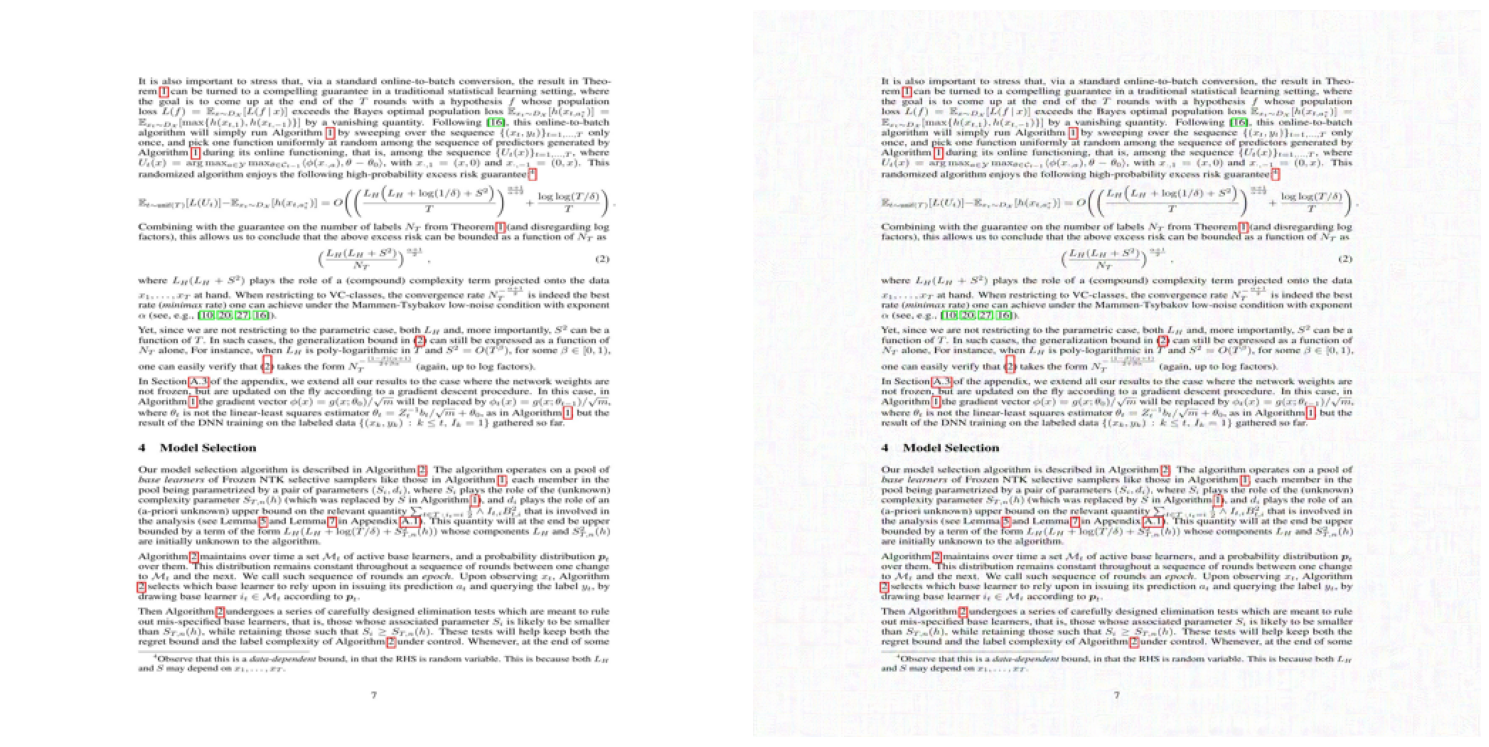

In [9]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [10]:
if test_retrieval:
    ds_dict = defaultdict(list)
    for i in range(len(ds)):
        ds_dict['image'].append(ds[i]['image'])
        ds_dict['index'].append(i)
    ds_dict['image'].append(T.ToPILImage()(image_adv/255))
    ds_dict['index'].append(len(ds))
    ds_adv = Dataset.from_dict(ds_dict)

In [11]:
if test_retrieval:
    ds_adv_with_embeddings = add_img_embedding_column(ds_adv, embedder, existing_col_name="image", new_col_name="image_embeddings", device=device)
    ds_adv_with_embeddings.add_faiss_index(column="image_embeddings")

### Retrieve most relevant image for each query

In [12]:
if test_retrieval:
    plot_images([ds[chosen_index]['image'], ds_adv_with_embeddings[1000]['image'], T.ToPILImage()(image_adv/255)], n_subplots=3)
    image_adv

In [13]:
if test_retrieval:
    topk=1

    indices = []
    for i in range(100):
        scores, retrieved = retrieve_images_by_prompt(query_strings[i], ds_adv_with_embeddings, embedder, topk, device, plot=False)
        indices.append(retrieved["index"][0])

    print(f"Number of queries for which the adversarial image is retrieved: {sum(torch.tensor(indices) == 1000).item()}/100")

### Test Generation

In [19]:
if test_generation:
    q_id = 66
    out_init = vlm.generate(initial_chosen_image, query_strings[q_id]) # this is the image we started with
    out_adv = vlm.generate(image_adv, query_strings[q_id]) # this is the image we optimized but after potentially being modified by the processor
    out_adv_ow = vlm.generate(image_adv, query_strings[q_id], overwrite=True) # this is the image we optimized
    print(out_init, out_adv, out_adv_ow, sep="\n===\n")

User:How does the delivery and assessment of course content differ between traditional and asynchronous courses?
Assistant: The delivery and assessment of course content differ between traditional and asynchronous courses in that traditional courses are delivered at a single point in time, while asynchronous courses allow students to access course material at any time and from any device.
===
User:How does the delivery and assessment of course content differ between traditional and asynchronous courses?
Assistant: In traditional courses, the instructor delivers the course content through a classroom setting, either in-person or remotely. The instructor guides the students through the material, and students work individually or in small groups to complete assignments and projects. In asynchronous courses, the instructor sends assignments and assessments via email or other communication channels. Students complete the assignments and projects independently, as they have the time and spac

In [15]:
if device == "mps": print(f"Allocated RAM: {torch.mps.current_allocated_memory()/1e9:.2f} GB")
if device == "cuda": print(f"Allocated VRAM: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Allocated RAM: 2.63 GB
